<div style="padding: 2.2rem 2.4rem; border-radius: 22px; background: linear-gradient(125deg, #102a43 0%, #1f6f78 58%, #4c956c 100%); color: white; box-shadow: 0 12px 30px rgba(16,42,67,.18);">
  <div style="font-size: .78rem; letter-spacing: .16em; opacity: .8; text-transform: uppercase;">Qwen3-4B · BF16 · RTX 4090</div>
  <h1 style="margin: .55rem 0 .7rem; color: white; font-size: 2.35rem;">FFN 通道置换：从数学等价到可观测行为</h1>
  <p style="font-size: 1.08rem; line-height: 1.75; margin: 0; max-width: 900px; opacity: .95;">
    一个看似只给神经元“重新编号”的操作，为什么会改变 GPU 推理结果？哪些置换能做到逐比特免费？
    微小数值漂移又会怎样传到 logits、生成路径与 benchmark？
  </p>
  <div style="margin-top: 1.25rem; display:flex; gap:.55rem; flex-wrap:wrap;">
    <span style="background:#ffffff22;padding:.35rem .7rem;border-radius:999px;">核心实验导览</span>
    <span style="background:#ffffff22;padding:.35rem .7rem;border-radius:999px;">直接读取原始汇总</span>
    <span style="background:#ffffff22;padding:.35rem .7rem;border-radius:999px;">无需 GPU</span>
  </div>
</div>

> **阅读方式**：这是整个实验系列的可执行入口。正文先给结论，再用四组锚点结果逐层展开。所有图表均由仓库内的 JSON/JSONL 现场生成，而不是手工录入。

## 先看结论

<div style="display:grid;grid-template-columns:repeat(2,minmax(260px,1fr));gap:14px;margin:18px 0;">
  <div style="padding:18px;border:1px solid #d7e3ea;border-radius:16px;background:#f7fbfc;"><b style="color:#1f6f78;">01 · 等价性成立</b><br><span style="color:#526777;line-height:1.65;">同一置换必须同时作用于 gate、up 的行与 down 的列。正确联动与错误做法之间有两个数量级以上的清晰分离。</span></div>
  <div style="padding:18px;border:1px solid #d7e3ea;border-radius:16px;background:#f7fbfc;"><b style="color:#1f6f78;">02 · 漂移来自归约</b><br><span style="color:#526777;line-height:1.65;">中间激活恢复原顺序后可与基线逐比特一致；首次差异锁定在 down projection 的并行求和路径。</span></div>
  <div style="padding:18px;border:1px solid #d7e3ea;border-radius:16px;background:#f7fbfc;"><b style="color:#1f6f78;">03 · 存在免费子空间</b><br><span style="color:#526777;line-height:1.65;">在当前部署栈中，只在对齐的八通道块内重排，可从单层保持到完整模型 logits 逐比特一致，并在六项 benchmark 上保持逐题 correctness 不变。</span></div>
  <div style="padding:18px;border:1px solid #d7e3ea;border-radius:16px;background:#f7fbfc;"><b style="color:#1f6f78;">04 · 几何距离不是旋钮</b><br><span style="color:#526777;line-height:1.65;">极小的跨块交换也可与全局随机置换落在同一漂移尺度；是否改变归约分组比通道移动多远更关键。</span></div>
  <div style="padding:18px;border:1px solid #d7e3ea;border-radius:16px;background:#f7fbfc;"><b style="color:#1f6f78;">05 · 参数扰动可落入同尺度</b><br><span style="color:#526777;line-height:1.65;">RandOpt 式方法会直接扰动权重并筛选候选。本仓库的响应标定显示，极小权重扰动有时可与 permutation 产生相近的 logits 漂移，但两者机制不同。</span></div>
  <div style="padding:18px;border:1px solid #d7e3ea;border-radius:16px;background:#f7fbfc;"><b style="color:#1f6f78;">06 · 模型训练阶段改变方向</b><br><span style="color:#526777;line-height:1.65;">二十个种子中，Base benchmark 偏移全为正，post-trained Instruct 全为负；种子离散程度接近，重复基线稳定性则不同。</span></div>
</div>

最重要的工程结论是：**如果目标是无损通道重排，应先在目标硬件与推理 kernel 上寻找并验证对齐块；如果允许跨块，则必须把它当作数值扰动，而不是纯粹的权重重命名。**

In [1]:
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import HTML, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "experiments" / "ffn_permutation").is_dir():
            return candidate
    raise FileNotFoundError("请从仓库内运行此 Notebook")

ROOT = find_repo_root()
EXP = ROOT / "experiments"

COLORS = {
    "navy": "#102a43",
    "teal": "#1f6f78",
    "green": "#4c956c",
    "gold": "#e9b949",
    "coral": "#df6c5b",
    "ink": "#334e68",
    "muted": "#829ab1",
    "paper": "#f7fbfc",
}

plt.rcParams.update({
    "figure.figsize": (10, 5.4),
    "figure.dpi": 120,
    "font.family": ["DejaVu Sans", "WenQuanYi Zen Hei", "Droid Sans Fallback"],
    "font.sans-serif": ["DejaVu Sans", "WenQuanYi Zen Hei", "Droid Sans Fallback"],
    "mathtext.fontset": "dejavusans",
    "axes.unicode_minus": False,
    "axes.facecolor": "#fbfdfe",
    "figure.facecolor": "white",
    "axes.edgecolor": "#d9e2ec",
    "axes.labelcolor": COLORS["ink"],
    "axes.titlecolor": COLORS["navy"],
    "xtick.color": COLORS["ink"],
    "ytick.color": COLORS["ink"],
    "grid.color": "#e8eef3",
    "grid.linewidth": 0.8,
    "font.size": 10.5,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

required = {
    "单层与全模型汇总": EXP / "ffn_permutation/results/summary.json",
    "最小代价分类": EXP / "permutation_min_cost/results/stage1b_classified.jsonl",
    "Benchmark 分布": EXP / "ffn_benchmark_eval/results/stage2_distribution.json",
    "噪声扫描": EXP / "noise_floor/results/part6_summary.json",
    "端到端验收": EXP / "noise_floor/results/acceptance_noise_floor.json",
}
missing = [name for name, path in required.items() if not path.is_file()]
assert not missing, f"缺少结果文件: {missing}"

display(pd.DataFrame({
    "证据": required.keys(),
    "仓库内路径": [str(p.relative_to(ROOT)) for p in required.values()],
    "状态": ["✓ 已找到"] * len(required),
}).style.hide(axis="index"))

print(f"仓库: {ROOT.name}")
print(f"运行环境: Python {platform.python_version()}")

证据,仓库内路径,状态
单层与全模型汇总,experiments/ffn_permutation/results/summary.json,✓ 已找到
最小代价分类,experiments/permutation_min_cost/results/stage1b_classified.jsonl,✓ 已找到
Benchmark 分布,experiments/ffn_benchmark_eval/results/stage2_distribution.json,✓ 已找到
噪声扫描,experiments/noise_floor/results/part6_summary.json,✓ 已找到
端到端验收,experiments/noise_floor/results/acceptance_noise_floor.json,✓ 已找到


仓库: permutation
运行环境: Python 3.13.5


## 研究对象与证据链

Qwen3 的 FFN 使用三个投影矩阵。对中间通道施加置换时，`gate_proj` 与 `up_proj` 需要同步重排行，`down_proj` 需要同步重排列。用矩阵记号写，就是：

$$
W_{gate}' = P W_{gate},\qquad
W_{up}' = P W_{up},\qquad
W_{down}' = W_{down}P^T.
$$

在精确实数计算下，置换会在进入 `down_proj` 前被完全抵消，模型函数不变。实际 GPU 使用有限精度与并行归约；乘积项虽然没变，分组和累加路径可能改变，因此结果可能在最低有效位附近发生漂移。

本系列按“局部算子 → 完整模型 → 行为评测 → 扰动标定”逐层建立证据，而不是只比较最终分数。

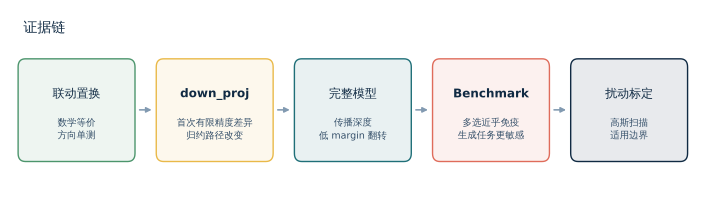

In [2]:
fig, ax = plt.subplots(figsize=(12.5, 3.5))
ax.set_xlim(0, 13.1)
ax.set_ylim(0, 3.3)
ax.axis("off")

nodes = [
    (0.25, "联动置换", "数学等价\n方向单测"),
    (2.85, "down_proj", "首次有限精度差异\n归约路径改变"),
    (5.45, "完整模型", "传播深度\n低 margin 翻转"),
    (8.05, "Benchmark", "多选近乎免疫\n生成任务更敏感"),
    (10.65, "扰动标定", "高斯扫描\n适用边界"),
]
node_colors = [COLORS["green"], COLORS["gold"], COLORS["teal"], COLORS["coral"], COLORS["navy"]]

for (x, title, subtitle), color in zip(nodes, node_colors):
    box = FancyBboxPatch(
        (x, 0.72), 2.1, 1.65,
        boxstyle="round,pad=0.05,rounding_size=0.14",
        linewidth=1.4, edgecolor=color, facecolor=color + "18"
    )
    ax.add_patch(box)
    ax.text(x + 1.05, 1.82, title, ha="center", va="center", fontsize=12, weight="bold", color=COLORS["navy"])
    ax.text(x + 1.05, 1.22, subtitle, ha="center", va="center", fontsize=9.5, color=COLORS["ink"], linespacing=1.45)

for left, right in zip(nodes, nodes[1:]):
    ax.annotate("", xy=(right[0] - .10, 1.55), xytext=(left[0] + 2.20, 1.55),
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color=COLORS["muted"]))

ax.text(.3, 2.88, "证据链", fontsize=14, weight="bold", color=COLORS["navy"])
plt.show()

## 锚点一：正确联动不是“近似正确”

第一轮实验先用合成矩阵校验方向，再在真实模型的首层、中层和末层 FFN 上建立十组正负对照。关键问题有两个：

- 正确联动能否与各种错误置换拉开明确距离？
- 差异到底在哪个算子首次出现？

下面左图比较正确联动与错误对照的单层漂移；右图比较同一类置换在不同注入深度下传到最终 logits 的大小。

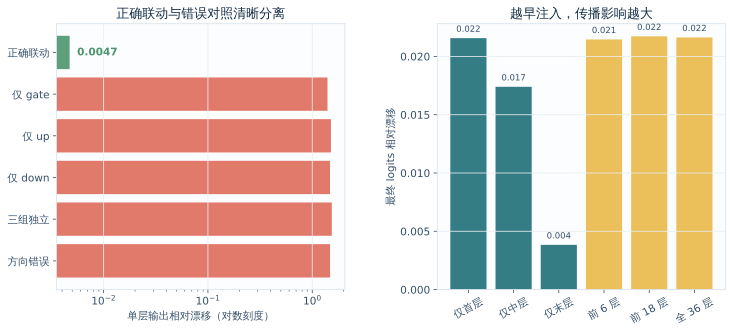

检查项,结果
合成矩阵方向单测,通过
canonical-down 隔离,True（120/120）
正确/错误中位分离倍数,316.5 倍
最坏分离倍数,235.4 倍


In [3]:
with open(EXP / "ffn_permutation/results/summary.json", encoding="utf-8") as f:
    perm_summary = json.load(f)

groups = perm_summary["stage_b"]["groups"]
group_order = ["valid-triplet", "gate-only", "up-only", "down-only", "independent-triplet", "wrong-direction"]
group_labels = ["正确联动", "仅 gate", "仅 up", "仅 down", "三组独立", "方向错误"]
group_values = [groups[k]["median_rel_l2"] for k in group_order]

cases = perm_summary["stage_c"]["cases"]
depth_order = ["one-layer-first", "one-layer-middle", "one-layer-last", "prefix-6", "half-18", "all-36"]
depth_labels = ["仅首层", "仅中层", "仅末层", "前 6 层", "前 18 层", "全 36 层"]
depth_values = []
for kind in depth_order:
    vals = [v["logits_rel_l2_median"] for k, v in cases.items() if k.startswith(kind + ":")]
    depth_values.append(float(np.median(vals)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"wspace": .32})

ax = axes[0]
bar_colors = [COLORS["green"]] + [COLORS["coral"]] * (len(group_values) - 1)
ax.barh(group_labels[::-1], group_values[::-1], color=bar_colors[::-1], alpha=.9)
ax.set_xscale("log")
ax.set_xlabel("单层输出相对漂移（对数刻度）")
ax.set_title("正确联动与错误对照清晰分离")
ax.grid(axis="x")
ax.text(group_values[0] * 1.18, 5, f"{group_values[0]:.4f}", va="center", color=COLORS["green"], weight="bold")

ax = axes[1]
ax.bar(depth_labels, depth_values, color=[COLORS["teal"]] * 3 + [COLORS["gold"]] * 3, alpha=.9)
ax.set_ylabel("最终 logits 相对漂移")
ax.set_title("越早注入，传播影响越大")
ax.grid(axis="y")
ax.tick_params(axis="x", rotation=28)
for i, value in enumerate(depth_values):
    ax.text(i, value + .00055, f"{value:.3f}", ha="center", fontsize=8.5, color=COLORS["ink"])

plt.show()

anchor = pd.DataFrame({
    "检查项": ["合成矩阵方向单测", "canonical-down 隔离", "正确/错误中位分离倍数", "最坏分离倍数"],
    "结果": [
        "通过",
        f'{perm_summary["stage_b"]["canonical_down_bitwise_all"]}（120/120）',
        f'{perm_summary["stage_b"]["separation_ratio_median"]:.1f} 倍',
        f'{perm_summary["stage_b"]["separation_ratio_worstcase"]:.1f} 倍',
    ],
})
display(anchor.style.hide(axis="index"))

**如何解读**

1. 正确联动后的单层误差很小，错误置换则让输出接近无关向量；这排除了“方向写错但碰巧还能跑”的可能。
2. 把置换后的中间激活恢复为原通道顺序，再送入原始 `down_proj`，全部样本与基线逐比特一致。说明 gate、up、激活函数与逐元素乘只做了坐标重排。
3. 全模型中，首次差异同样出现在被置换层的 MLP 输出。越早出现的误差有越长的传播路径，因此只改首层已经接近全层改动的影响。

## 锚点二：最小代价不是连续旋钮，而是对齐边界

后续实验系统扫描了局部窗口、相邻交换、块交换、稀疏全局交换和全局随机等置换族。最初预注册的是“漂移随几何距离连续变化”的假设；数据并不支持它。复审后出现了更简单的结构：

- **块内免费**：通道始终留在原来的对齐八通道块内；
- **狭窄过渡**：只在小窗口内跨过一部分边界；
- **跨块非零**：一旦实质改变归约分组，很快进入 backend 相关误差带。

最直观的反例是奇数起点的相邻交换：每个被换通道只移动一个位置，但其中零起始编号的第 7、8 号通道等配对刚好跨过八通道边界。这套置换在完整模型上的 logits 相对漂移中位数为 0.009489，与全局随机置换的 0.009879 处于同一数量级；相反，保持在对齐块内的相邻交换可以逐比特为零。

下图使用第二轮全新随机种子的 PyTorch BF16 矩阵乘结果。零值为了能出现在对数坐标上，仅在绘图时放到最下方；它们在原始记录中仍严格为零。

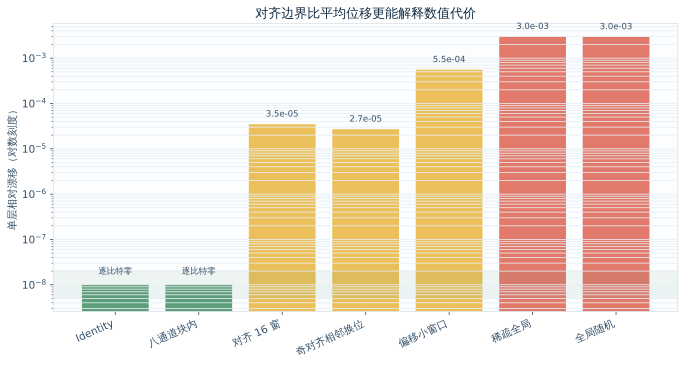

执行路径,块内置换,结论
PyTorch BF16 GEMM,126/126 逐比特一致,免费类成立
vLLM prefill,126/126 逐比特一致,免费类成立
vLLM decode,126/126 逐比特一致,免费类成立
PyTorch BF16 GEMV,存在极少量微漂移,不纳入逐比特保证


In [4]:
records = []
with open(EXP / "permutation_min_cost/results/stage1b_classified.jsonl", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

cost_df = pd.DataFrame({
    "family": [r["family"] for r in records],
    "backend": [r["backend"] for r in records],
    "shape": [r["shape"] for r in records],
    "tier": [r["predicted_tier"] for r in records],
    "rel_l2": [r["drift"]["rel_l2"] for r in records],
    "bitwise": [r["drift"]["bitwise_equal"] for r in records],
})

view = cost_df.query("backend == 'torch_bf16' and shape == 'full'")
agg = view.groupby("family", as_index=False).agg(
    median_rel_l2=("rel_l2", "median"),
    bitwise_rate=("bitwise", "mean"),
    tier=("tier", "first"),
)

family_order = ["F8_identity", "F9_inblock_shuffle", "F12_win16_aligned", "F10_odd_pairs", "F11_window_offset", "F3_scattered_global", "F7_global_random"]
name_map = {
    "F8_identity": "Identity",
    "F9_inblock_shuffle": "八通道块内",
    "F12_win16_aligned": "对齐 16 窗",
    "F10_odd_pairs": "奇对齐相邻换位",
    "F11_window_offset": "偏移小窗口",
    "F3_scattered_global": "稀疏全局",
    "F7_global_random": "全局随机",
}
agg = agg.set_index("family").loc[family_order].reset_index()
plot_values = agg["median_rel_l2"].replace(0, 1e-8)
family_color = {
    "F8_identity": COLORS["green"],
    "F9_inblock_shuffle": COLORS["green"],
    "F12_win16_aligned": COLORS["gold"],
    "F10_odd_pairs": COLORS["gold"],
    "F11_window_offset": COLORS["gold"],
    "F3_scattered_global": COLORS["coral"],
    "F7_global_random": COLORS["coral"],
}

fig, ax = plt.subplots(figsize=(11.2, 5.2))
bars = ax.bar(range(len(agg)), plot_values, color=[family_color[f] for f in agg["family"]], alpha=.9)
ax.set_yscale("log")
ax.set_xticks(range(len(agg)), [name_map[x] for x in agg["family"]], rotation=24, ha="right")
ax.set_ylabel("单层相对漂移（对数刻度）")
ax.set_title("对齐边界比平均位移更能解释数值代价")
ax.grid(axis="y", which="both")
ax.axhspan(5e-9, 2e-8, color=COLORS["green"], alpha=.08)

for bar, raw, rate in zip(bars, agg["median_rel_l2"], agg["bitwise_rate"]):
    label = "逐比特零" if raw == 0 else f"{raw:.1e}"
    ax.text(bar.get_x() + bar.get_width()/2, max(bar.get_height()*1.35, 1.6e-8), label,
            ha="center", va="bottom", fontsize=8.5, color=COLORS["ink"])

plt.show()

free_scope = pd.DataFrame({
    "执行路径": ["PyTorch BF16 GEMM", "vLLM prefill", "vLLM decode", "PyTorch BF16 GEMV"],
    "块内置换": ["126/126 逐比特一致", "126/126 逐比特一致", "126/126 逐比特一致", "存在极少量微漂移"],
    "结论": ["免费类成立", "免费类成立", "免费类成立", "不纳入逐比特保证"],
})
display(free_scope.style.hide(axis="index"))

这条边界是当前硬件与 kernel 的**实测属性**，不是架构常数。尤其要区分矩阵乘与单行向量乘：它们可能选择不同的归约 kernel。部署环境、GPU、dtype 或库版本变化后，应先重跑逐比特 smoke test。

最终端到端验收进一步确认：冻结的 vLLM 配置下，同权重重复运行的三十二条 prompt 全部逐比特一致；全模型块内置换同样全部逐比特一致；六项 benchmark 的逐题 correctness 零差。这里的 benchmark 判据是“每题对错是否改变”，不是所有生成文本都逐字节相同；GSM8K 有三条响应文本不同，但抽取答案的正确性不变。

## 锚点三：跨块漂移如何传到 benchmark

主评测覆盖两个同架构模型、二十组全层随机置换，以及六项 benchmark。每组置换都保持三矩阵正确联动，只改变有限精度执行路径。

第一张图复用 `docs` 中最直观的表达：每条胶囊表示二十个置换种子的完整观察范围，圆点是均值，浅色竖带表示相对基线变化不超过一个百分点。两个模型使用完全相同的横轴，底部淡红区域标出长生成任务，因此可以直接比较扰动影响的方向、大小和任务类型。

第二张图再把每个 seed 的六任务平均分全部展开，避免只看均值掩盖分布。

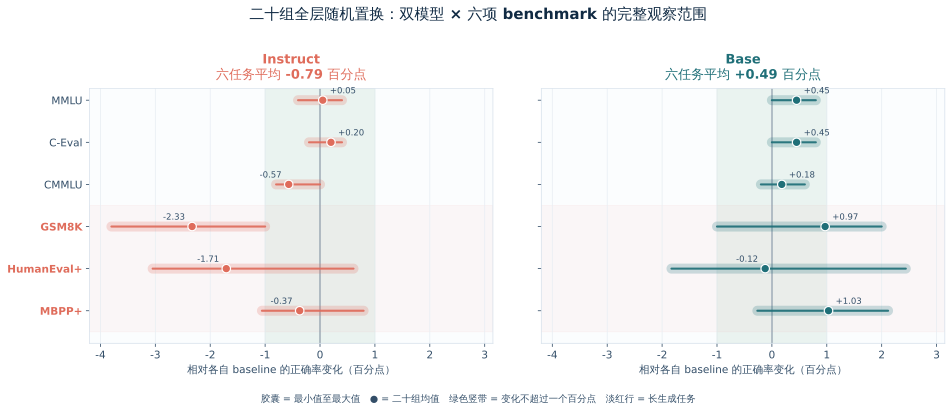

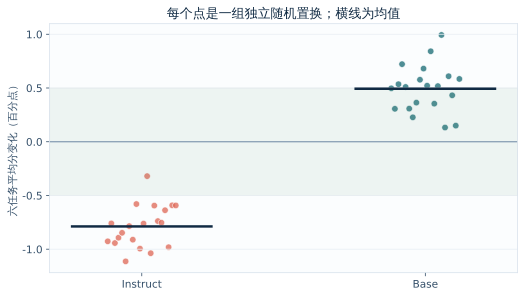

模型,二十组均值,种子间标准差,观察范围
Qwen3-4B Instruct,-0.79,0.19,"[-1.11, -0.32]"
Qwen3-4B Base,+0.49,0.21,"[0.13, 0.99]"


任务,Instruct baseline,Instruct 置换均值,Base baseline,Base 置换均值
MMLU,69.00,69.05,73.80,74.25
C-Eval,83.20,83.40,86.00,86.45
CMMLU,75.20,74.63,78.80,78.98
GSM8K,75.60,73.27,77.20,78.17
HumanEval+,70.12,68.41,56.10,55.98
MBPP+,60.85,60.48,61.90,62.94


In [5]:
BENCHES = ["mmlu", "gsm8k", "ceval", "cmmlu", "humaneval_plus", "mbpp_plus"]
DISPLAY_BENCHES = ["mmlu", "ceval", "cmmlu", "gsm8k", "humaneval_plus", "mbpp_plus"]
bench_labels = {
    "mmlu": "MMLU",
    "ceval": "C-Eval",
    "cmmlu": "CMMLU",
    "gsm8k": "GSM8K",
    "humaneval_plus": "HumanEval+",
    "mbpp_plus": "MBPP+",
}

def accuracy(tag, bench):
    path = EXP / "ffn_benchmark_eval/results/raw" / tag / f"{bench}.raw.json"
    with open(path, encoding="utf-8") as f:
        return json.load(f)["accuracy"]

families = {
    "Instruct": "qwen3_4b",
    "Base": "qwen3_4b_base",
}
seed_rows = []
baseline_scores = {}
for model_name, family in families.items():
    baseline = {b: accuracy(f"{family}__baseline_original_run1", b) for b in BENCHES}
    baseline_scores[model_name] = baseline
    for seed in range(1000, 1020):
        deltas = {
            b: (accuracy(f"{family}__perm_all36_s{seed}", b) - baseline[b]) * 100
            for b in BENCHES
        }
        seed_rows.append({"model": model_name, "seed": seed, "macro_delta_pp": np.mean(list(deltas.values())), **deltas})

seed_df = pd.DataFrame(seed_rows)
with open(EXP / "ffn_benchmark_eval/results/stage2_distribution.json", encoding="utf-8") as f:
    stage2 = json.load(f)

# 与 docs 首页一致的 min–max range chart，但直接从结果 JSON 重建。
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8), sharex=True, sharey=True, gridspec_kw={"wspace": .12})
model_specs = [
    ("Instruct", "qwen3_4b", COLORS["coral"]),
    ("Base", "qwen3_4b_base", COLORS["teal"]),
]
y = np.arange(len(DISPLAY_BENCHES))

for ax, (model, family, color) in zip(axes, model_specs):
    ax.axvspan(-1, 1, color=COLORS["green"], alpha=.09, zorder=0)
    ax.axhspan(2.5, 5.5, color=COLORS["coral"], alpha=.045, zorder=0)
    ax.axvline(0, color=COLORS["navy"], lw=1.2, alpha=.72, zorder=1)
    for row, bench in enumerate(DISPLAY_BENCHES):
        stats = stage2[family]["per_bench"][bench]["delta_pp"]
        ax.plot([stats["min"], stats["max"]], [row, row], color=color, lw=10,
                alpha=.22, solid_capstyle="round", zorder=2)
        ax.plot([stats["min"], stats["max"]], [row, row], color=color, lw=2.1,
                alpha=.92, solid_capstyle="round", zorder=3)
        ax.scatter(stats["mean"], row, s=72, color=color, edgecolor="white", linewidth=1.2, zorder=4)
        ax.text(stats["mean"] + (.13 if stats["mean"] >= 0 else -.13), row - .22,
                f'{stats["mean"]:+.2f}', ha="left" if stats["mean"] >= 0 else "right",
                va="center", fontsize=8.5, color=COLORS["ink"])
    macro = stage2[family]["suite_macro_delta_pp"]
    ax.set_title(f'{model}\n六任务平均 {macro["mean"]:+.2f} 百分点', color=color, pad=10)
    ax.set_xlim(-4.2, 3.15)
    ax.set_xticks(np.arange(-4, 4, 1))
    ax.set_xlabel("相对各自 baseline 的正确率变化（百分点）")
    ax.grid(axis="x")

axes[0].set_yticks(y, [bench_labels[b] for b in DISPLAY_BENCHES])
axes[0].invert_yaxis()
for tick, bench in zip(axes[0].get_yticklabels(), DISPLAY_BENCHES):
    if bench in {"gsm8k", "humaneval_plus", "mbpp_plus"}:
        tick.set_weight("bold")
        tick.set_color(COLORS["coral"])

fig.suptitle("二十组全层随机置换：双模型 × 六项 benchmark 的完整观察范围",
             fontsize=15, weight="bold", color=COLORS["navy"], y=.975)
fig.text(.5, .03, "胶囊 = 最小值至最大值　● = 二十组均值　绿色竖带 = 变化不超过一个百分点　淡红行 = 长生成任务",
         ha="center", color=COLORS["ink"], fontsize=9.5)
fig.subplots_adjust(left=.10, right=.98, bottom=.17, top=.78, wspace=.12)
plt.show()

# suite macro 的逐 seed 分布：所有点都保留，不只报告均值。
fig, ax = plt.subplots(figsize=(8.4, 4.5))
for idx, (model, color) in enumerate([("Instruct", COLORS["coral"]), ("Base", COLORS["teal"])]) :
    values = seed_df.loc[seed_df.model == model, "macro_delta_pp"].to_numpy()
    x = np.full(len(values), idx) + np.linspace(-.12, .12, len(values))
    ax.scatter(x, values, s=42, color=color, alpha=.78, edgecolor="white", linewidth=.65)
    ax.hlines(values.mean(), idx-.25, idx+.25, color=COLORS["navy"], lw=2.5)
ax.axhspan(-.5, .5, color=COLORS["green"], alpha=.08)
ax.axhline(0, color=COLORS["muted"], lw=1.2)
ax.set_xticks([0, 1], ["Instruct", "Base"])
ax.set_ylabel("六任务平均分变化（百分点）")
ax.set_title("每个点是一组独立随机置换；横线为均值")
ax.grid(axis="y")
plt.show()

macro_summary = pd.DataFrame({
    "模型": ["Qwen3-4B Instruct", "Qwen3-4B Base"],
    "二十组均值": [
        stage2["qwen3_4b"]["suite_macro_delta_pp"]["mean"],
        stage2["qwen3_4b_base"]["suite_macro_delta_pp"]["mean"],
    ],
    "种子间标准差": [
        stage2["qwen3_4b"]["suite_macro_delta_pp"]["std"],
        stage2["qwen3_4b_base"]["suite_macro_delta_pp"]["std"],
    ],
    "观察范围": [
        f'[{stage2["qwen3_4b"]["suite_macro_delta_pp"]["min"]:.2f}, {stage2["qwen3_4b"]["suite_macro_delta_pp"]["max"]:.2f}]',
        f'[{stage2["qwen3_4b_base"]["suite_macro_delta_pp"]["min"]:.2f}, {stage2["qwen3_4b_base"]["suite_macro_delta_pp"]["max"]:.2f}]',
    ],
})
display(macro_summary.style.hide(axis="index").format({"二十组均值": "{:+.2f}", "种子间标准差": "{:.2f}"}))

absolute_rows = []
for bench in DISPLAY_BENCHES:
    row = {"任务": bench_labels[bench]}
    for model in ["Instruct", "Base"]:
        base_pp = baseline_scores[model][bench] * 100
        mean_delta = seed_df.loc[seed_df.model == model, bench].mean()
        row[f"{model} baseline"] = base_pp
        row[f"{model} 置换均值"] = base_pp + mean_delta
    absolute_rows.append(row)

display(pd.DataFrame(absolute_rows).style.hide(axis="index").format({
    "Instruct baseline": "{:.2f}",
    "Instruct 置换均值": "{:.2f}",
    "Base baseline": "{:.2f}",
    "Base 置换均值": "{:.2f}",
}))

**边界与解释**

- 多选任务的逐题行为基本稳定，变化主要集中在需要长程自回归生成的任务。
- 二十个置换种子中，Base 的 suite 偏移全部为正，post-trained Instruct 全部为负；这是稳定的方向分离，说明不能把随机置换解释成天然增益或天然退化。
- 两组种子偏移的标准差分别约为 0.21 和 0.19 个百分点，数值接近，不能表述为显著的种子方差差异。更清楚的稳定性差异来自同权重重复运行：Base 六项 correctness 全部稳定，Instruct 的 GSM8K 存在运行波动，但无运行噪声的 HumanEval+ 仍表现出布局效应。
- 在半份数据上挑出的最好置换，其优势换到另一半数据后基本消失。当前证据不支持通过挑 seed 获得可迁移能力提升。

## 锚点四：与高斯权重扰动放在同一刻度

RandOpt 一类方法直接对权重加参数扰动，再依据目标分数筛选候选，思路上接近零阶优化。这里没有运行完整的 RandOpt 搜索，而是用十档全模型 BF16 高斯权重扰动标定 logits 响应，并与全层随机置换参考线比较。实验前预测小扰动端会先出现逐比特零区，再进入平台；实际结果推翻了这个预测。

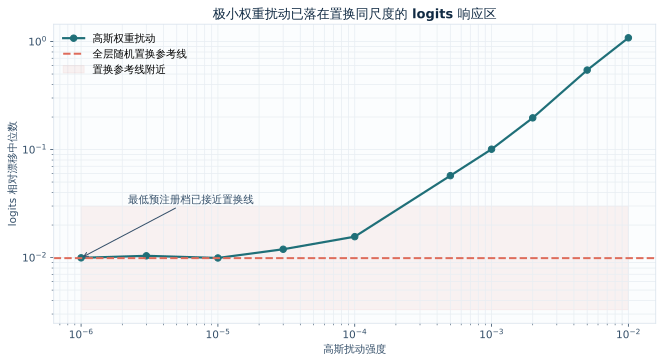

判据,类型,结果,证据文件
S0-1,硬判据,pass,results/part0_compare.json
S1-1,硬判据,pass,results/part1a_summary.json
S1-2,软判据 / 预测,pass,results/part1a_summary.json
S1-3,硬判据,pass,results/part1b_compare.json
S1-4,软判据 / 预测,pass,results/part1b_compare.json
S2-1,软判据 / 预测,fail,results/part2_summary.json
P6-1,软判据 / 预测,fail,results/part6_summary.json
P6-2,软判据 / 预测,fail,results/part6_summary.json


In [6]:
with open(EXP / "noise_floor/results/part6_summary.json", encoding="utf-8") as f:
    noise = json.load(f)
with open(EXP / "noise_floor/results/acceptance_noise_floor.json", encoding="utf-8") as f:
    acceptance = json.load(f)

curve = pd.DataFrame(noise["curve"])
fig, ax = plt.subplots(figsize=(10.8, 5.4))
ax.plot(curve["sigma"], curve["median_rel_l2"], marker="o", ms=6.5, lw=2.2, color=COLORS["teal"], label="高斯权重扰动")
ax.axhline(noise["f7_reference_median_rel_l2"], color=COLORS["coral"], lw=2, ls="--", label="全层随机置换参考线")
ax.fill_between(curve["sigma"], noise["f7_reference_median_rel_l2"]/3, noise["f7_reference_median_rel_l2"]*3,
                color=COLORS["coral"], alpha=.08, label="置换参考线附近")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("高斯扰动强度")
ax.set_ylabel("logits 相对漂移中位数")
ax.set_title("极小权重扰动已落在置换同尺度的 logits 响应区")
ax.grid(which="both")
ax.legend(frameon=False, loc="upper left")
ax.annotate("最低预注册档已接近置换线", xy=(curve.iloc[0].sigma, curve.iloc[0].median_rel_l2),
            xytext=(2.2e-6, 3.2e-2), arrowprops=dict(arrowstyle="->", color=COLORS["ink"]), color=COLORS["ink"])
plt.show()

criteria_rows = []
for key, value in acceptance["criteria"].items():
    criteria_rows.append({
        "判据": key,
        "类型": "硬判据" if value.get("hard") else "软判据 / 预测",
        "结果": value["status"],
        "证据文件": value["evidence"],
    })
display(pd.DataFrame(criteria_rows).style.hide(axis="index"))

最低预注册档已经与随机置换参考线处在同一尺度，补充实验继续降低扰动后仍未观察到逐比特零区。需要谨慎区分两件事：置换不改变精确函数，而高斯扰动真实改变权重；两者的 logits 漂移接近，**不等于**已经证明所有方法都存在统一的测量下限，也不等于已经找到了更好的权重。

本实验没有保存中间 activation，因此证据只支持“参数改动经过模型传播后，在最终 logits 上形成了同尺度响应”，不能据此定位某一层 activation 的具体传播路径。

行为层补充分析发现，小扰动与置换在 top-1 翻转、分布距离和候选重叠等描述性指标上处于相近范围；这不是统计等价性检验。明显分离要到更大的扰动档。翻转仍集中在低 margin prompt，这与最早的全模型实验形成闭环。

## 最终认识：三条可操作规则

| 场景 | 应采用的规则 | 当前证据 |
|---|---|---|
| 必须严格保持张量输出 | 只使用目标执行栈上验证过的块内置换，并做端到端逐比特 smoke test | 三十二条探针 logits 逐比特一致；六项 benchmark correctness 零差 |
| 允许轻微行为扰动 | 将任何跨块置换视作 backend 相关数值扰动；同时报告 logits 与逐题行为 | 跨块后进入非零误差带，生成任务更敏感 |
| 想从置换中挑“更好模型” | 必须用独立 held-out 数据复验，不能在同一评测集挑 seed 后宣称能力提升 | 半数据挑选优势换半后基本消失 |

### 仍未解决

1. Instruct 与 Base 在当前 benchmark 上方向相反的深层机制；
2. 配对零阶探针在统一损失口径下的真实信噪比；
3. 换 GPU、dtype、kernel 或模型架构后，对齐块与误差带是否保持；
4. 原应用目标中的真实 expert 匹配与合并，以及 MoE router 索引的同步处理。

### 继续阅读

- [面向外部读者的整体报告](../docs/reports/overall_report.md)
- [逐实验完整索引](../docs/reports/experiment_index.md)
- [FFN permutation 原始结论](../experiments/ffn_permutation/RESULT.md)
- [最小代价置换总览](../experiments/permutation_min_cost/OVERVIEW.md)
- [Benchmark 完整结果](../experiments/ffn_benchmark_eval/RESULT.md)
- [最终轮执行报告](../experiments/noise_floor/EXECUTION_REPORT.md)

In [7]:
# 最后的机器可读一致性检查：只验证本 Notebook 引用的关键事实。
assert perm_summary["stage_b"]["canonical_down_bitwise_all"] is True
assert perm_summary["stage_b"]["separation_ratio_worstcase"] > 200
assert acceptance["criteria"]["S0-1"]["status"] == "pass"
assert acceptance["criteria"]["S1-1"]["status"] == "pass"
assert acceptance["criteria"]["S1-3"]["status"] == "pass"
assert acceptance["criteria"]["P6-2"]["status"] == "fail"  # 保留被推翻的预测
assert len(seed_df) == 40
assert (seed_df.query("model == 'Instruct'").macro_delta_pp < 0).all()
assert (seed_df.query("model == 'Base'").macro_delta_pp > 0).all()

# 检查本 Notebook 实际消费的 42 个 tag × 6 项 benchmark，而不只信任聚合文件。
expected_counts = {
    "mmlu": 500,
    "gsm8k": 500,
    "ceval": 500,
    "cmmlu": 500,
    "humaneval_plus": 164,
    "mbpp_plus": 378,
}
checked_raw = 0
for model_name, family in families.items():
    tags = [f"{family}__baseline_original_run1"] + [f"{family}__perm_all36_s{seed}" for seed in range(1000, 1020)]
    for tag in tags:
        for bench, expected in expected_counts.items():
            raw_path = EXP / "ffn_benchmark_eval/results/raw" / tag / f"{bench}.raw.json"
            with open(raw_path, encoding="utf-8") as f:
                raw = json.load(f)
            assert raw["complete"] is True
            assert raw["total"] == expected == len(raw["samples"])
            assert raw["correct"] == sum(bool(sample["correct"]) for sample in raw["samples"])
            assert np.isclose(raw["accuracy"], raw["correct"] / raw["total"])
            checked_raw += 1

# 核对逐 seed 重算结果与 stage2 聚合中的核心统计量一致。
for model_name, family in families.items():
    model_rows = seed_df.query("model == @model_name")
    for bench in BENCHES:
        values = model_rows[bench].to_numpy()
        stats = stage2[family]["per_bench"][bench]["delta_pp"]
        assert stats["n"] == 20
        assert np.isclose(stats["mean"], values.mean())
        assert np.isclose(stats["min"], values.min())
        assert np.isclose(stats["max"], values.max())
    macro = model_rows["macro_delta_pp"].to_numpy()
    macro_stats = stage2[family]["suite_macro_delta_pp"]
    assert np.isclose(macro_stats["mean"], macro.mean())
    assert np.isclose(macro_stats["min"], macro.min())
    assert np.isclose(macro_stats["max"], macro.max())

assert checked_raw == 252

display(HTML(
    '<div style="margin-top:12px;padding:16px 18px;border-left:5px solid #4c956c;'
    'background:#f1f8f4;border-radius:10px;color:#334e68;">'
    '<b>✓ Notebook 校验通过</b><br>'
    '关键结论、252 份相关 raw 文件及其聚合统计均已从当前仓库重新加载并通过一致性断言。'
    '</div>'
))